In [1]:
# QSS 20 Final Project
# Cooper Hindshaw

# 03_replication_analysis.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_stata("../dataverse_files/UCT_FINAL_CLEAN.dta")

print("Dataset shape:")
print(df.shape)

# Keep observations with both baseline and follow-up assets
rep = df[
    ["surveyid",
     "treat",
     "asset_total_ppp0",
     "asset_total_ppp1"]
    ].dropna().copy()

# Rename variables to make the code easier to read
rep = rep.rename(
    columns={"asset_total_ppp0": "assets_baseline",
             "asset_total_ppp1": "assets_followup"})

# Change in assets
rep["asset_change"] = (rep["assets_followup"] -rep["assets_baseline"])

# Balboni uses log assets.
# log1p allows households with zero assets to remain in the sample.
rep["log_assets_baseline"] = np.log1p(rep["assets_baseline"])
rep["log_assets_followup"] = np.log1p(rep["assets_followup"])

# Change in log assets
rep["log_asset_change"] = (rep["log_assets_followup"] -rep["log_assets_baseline"])

print("\nAnalysis sample:")
print(rep.shape)

print("\nSummary statistics:")
display(rep[["assets_baseline",
             "assets_followup",
             "asset_change"]].describe())


Dataset shape:
(2880, 981)

Analysis sample:
(2880, 8)

Summary statistics:


,assets_baseline,assets_followup,asset_change
count,2880.000000,2880.000000,2880.000000
mean,267.174622,536.925171,269.750580
std,369.133728,454.425568,461.792358
min,0.000000,0.000000,-3250.860352
25%,0.000000,193.192886,17.994069
50%,165.232559,385.386078,202.799217
75%,368.405304,826.012741,534.301819
max,4424.277832,2561.091064,1987.409668


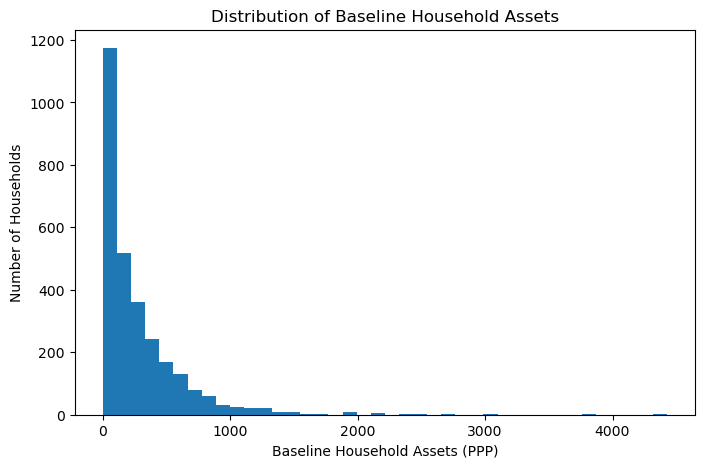

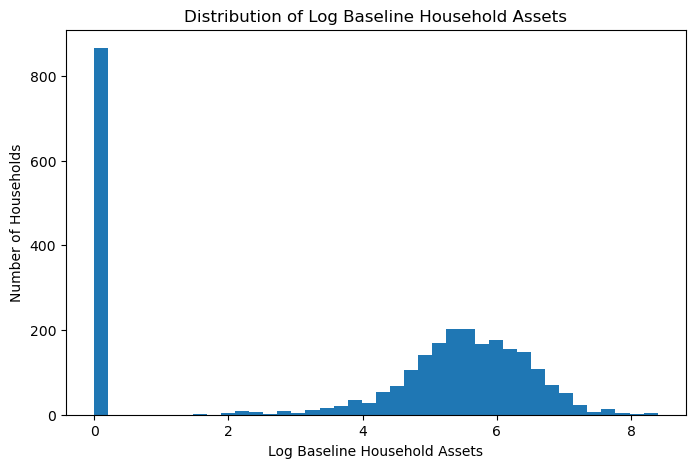

In [2]:
# Baseline Distribution
# Balboni style exploratory analysis

plt.figure(figsize=(8, 5))

plt.hist(
    rep["assets_baseline"],
    bins=40)

plt.xlabel("Baseline Household Assets (PPP)")
plt.ylabel("Number of Households")
plt.title("Distribution of Baseline Household Assets")

plt.savefig(
    "../output/replication_baseline_asset_distribution.png",
    bbox_inches="tight")

plt.show()

# 4. LOG BASELINE ASSET DISTRIBUTION
# Makes the distribution easier to examine because
# asset holdings are highly skewed

plt.figure(figsize=(8, 5))

plt.hist(
    rep["log_assets_baseline"],
    bins=40)

plt.xlabel("Log Baseline Household Assets")
plt.ylabel("Number of Households")
plt.title("Distribution of Log Baseline Household Assets")

plt.savefig(
    "../output/replication_log_asset_distribution.png",
    bbox_inches="tight")

plt.show()




